## Generalized Lotka-Volterra

In [1]:
%%capture
%load_ext autoreload
%autoreload 2
%reset -f
# %pip install matplotlib

In [2]:
import jax
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt

import sys
import os

# Add the parent folder (OTF) to sys.path
project_root = os.path.abspath(os.path.join("..", "..", "src"))
sys.path.append(project_root)

import otf
from otf import optim
from otf import time_integration as ti
from otf.asyncd import utils
from otf.system import System_ModelKnown

from plot import plot
from plot import plot_with_param_errors

import numpy as np

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)

jndarray = jnp.ndarray

In [5]:
def get_initial_values(N):
    # Random starting populations between 0.1 and 1.5
    u0 = jnp.array(jax.random.uniform(jax.random.PRNGKey(0), (N,), minval=0.1, maxval=1.5))
    un0 = u0
    return u0, un0

def lotka_volterra(gs: jndarray, x: jndarray) -> jndarray:
    """
    gs contains parameters:
        first N entries  -> growth rates b
        remaining N*N    -> flattened interaction matrix A
    """
    N = x.shape[0]
    b = gs[:N]
    A = gs[N:].reshape((N, N))
    dx = x * (b + A @ x)
    return dx

N = 9 # number of species

# Growth rates (b_i > 0)
b = jnp.array([1.0 + 0.1*i for i in range(N)])

# Interaction matrix A: negative diagonal, small off-diagonal
A = -jnp.eye(N) * 1.0 + 0.1 * jnp.array(jax.random.uniform(jax.random.PRNGKey(1), (N, N), minval=-0.2, maxval=0.2))

gs = jnp.concatenate([b, A.flatten()])

# Slightly perturbed initial parameter guess for assimilation
cs = gs + 0.5 * jnp.ones_like(gs)

# Initial populations
true0, assimilated0 = get_initial_values(N)

mu = 20
observed_slice = jnp.s_[:]
observed_mask = otf.system.utils.mask_from_slice(observed_slice, true0.shape)

system = System_ModelKnown(mu, gs, cs, observed_mask, lotka_volterra, lotka_volterra)

solver = ti.ForwardEuler(system)
solver = ti.TwoStepAdamsBashforth(system, solver)

optimizer = optax.adam(5e-4)
optimizer = optim.OptaxWrapper(system, optimizer)

dt = 0.01
T0, Tf = 0, 10000
t_relax = 1

trues, tls_ = solver.solve_true(true0, T0, Tf, dt)
true_observed = trues[:, system.observed_mask]

cs, u_errors, tls, assimilateds = utils.run_update(
    system,
    true_observed,
    solver,
    dt,
    T0,
    Tf,
    t_relax,
    assimilated0,
    optimizer=optimizer,
    return_all=True,
)

# cs = np.nan_to_num(cs, nan=0.0, posinf=1e6, neginf=-1e6)
cs = np.asarray(cs)
cs[~np.isfinite(cs)] = np.nan
subset = np.random.choice(N + N*N, size=6, replace=False)
fig, axs = plot(cs, u_errors, gs, tls, param_indices=subset)
plt.show()


subset = np.random.choice(cs.shape[1], size=5, replace=False)
fig, axs = plot_with_param_errors(cs, gs, tls, param_indices=subset)
plt.show()

ValueError: assignment destination is read-only

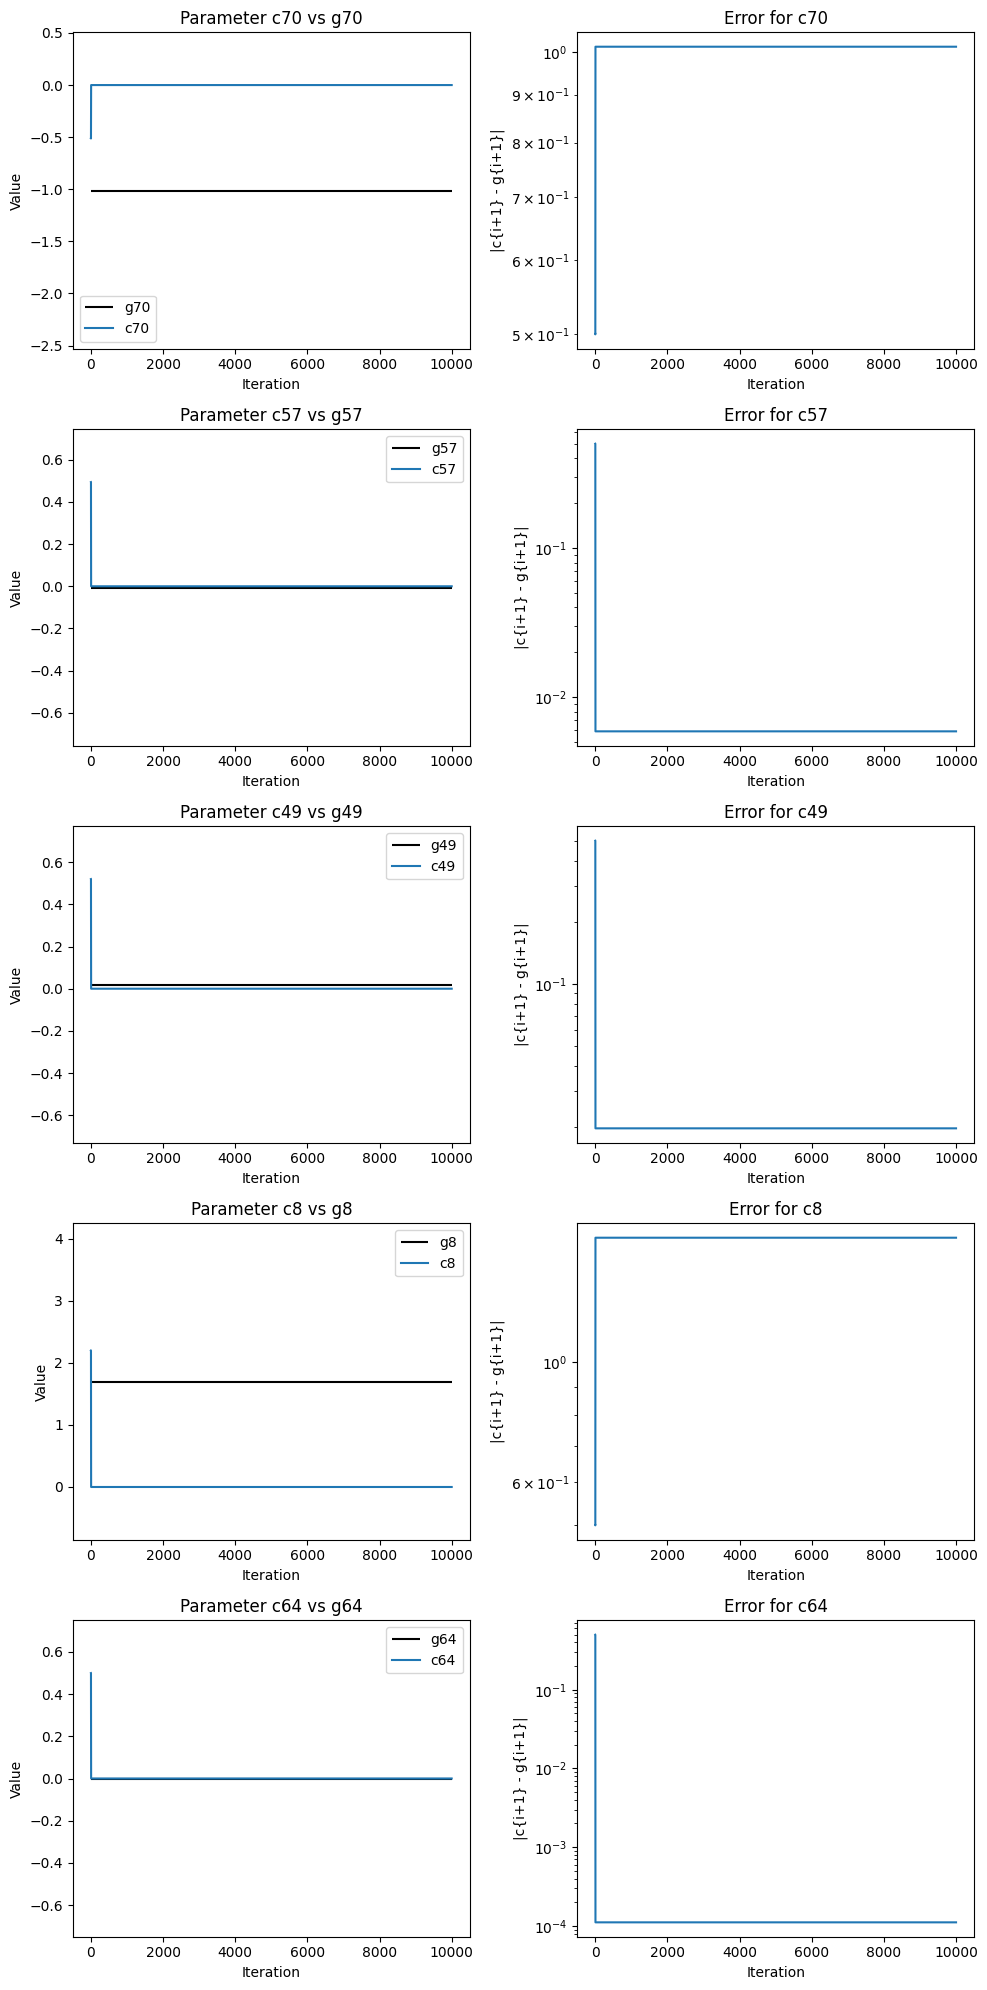

In [4]:
subset = np.random.choice(cs.shape[1], size=5, replace=False)
fig, axs = plot_with_param_errors(cs, gs, tls, param_indices=subset)
plt.show()